## NAV Trend Analysis

1) The average NAV across all schemes showed a steady upward trend between 2022 and 2026.

2) Periods of stronger growth indicate bullish market conditions, while temporary declines reflect market corrections.

3) Overall, mutual fund NAVs demonstrated long-term appreciation.

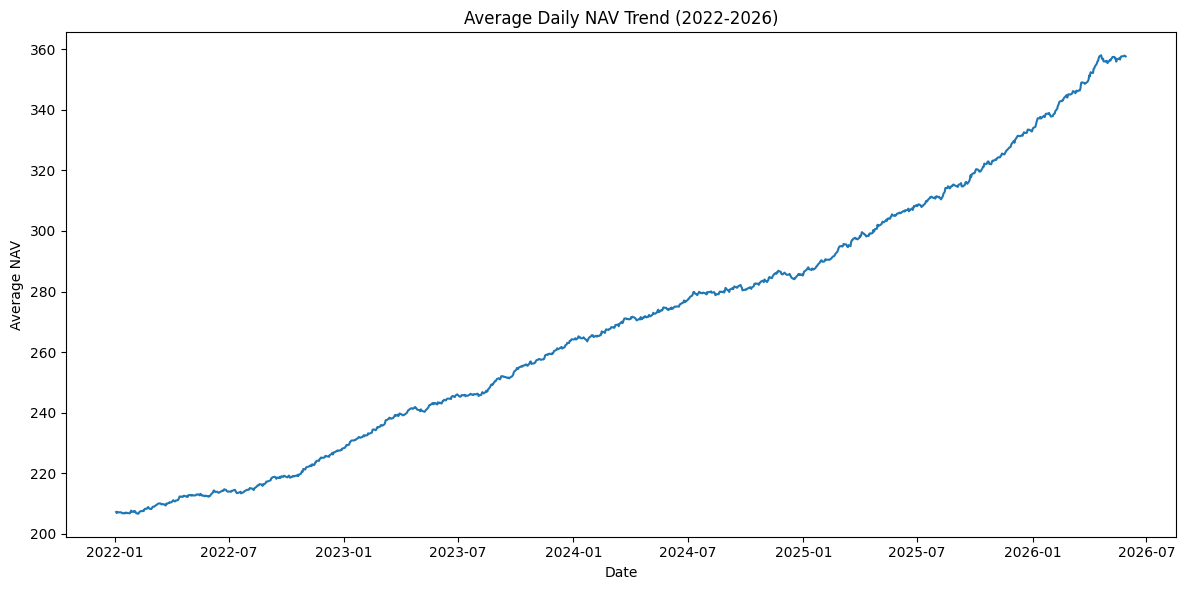

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
nav["date"] = pd.to_datetime(nav["date"])
daily_nav = nav.groupby("date")["nav"].mean()

plt.figure(figsize=(12,6))
plt.plot(daily_nav.index, daily_nav.values)

plt.title("Average Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.tight_layout()
plt.savefig("../charts/nav_trend.png")
plt.show()

## AUM Growth by Fund House

1) This chart compares Assets Under Management (AUM) across fund houses over time.

2) Higher AUM indicates stronger investor confidence and larger market share.

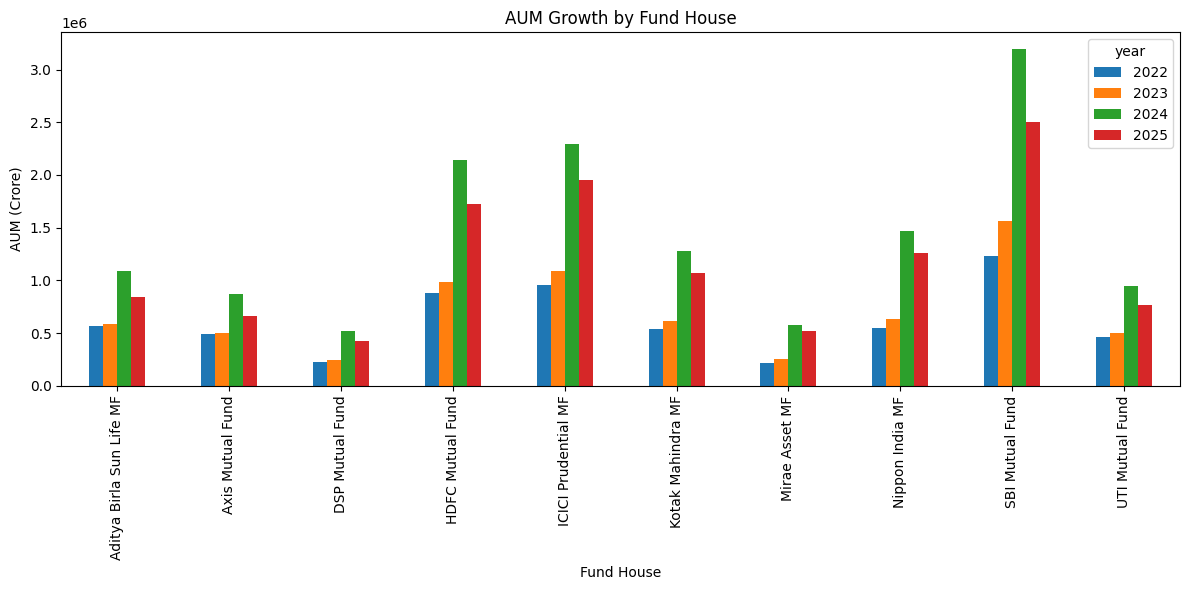

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

grouped = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

pivot = grouped.pivot(
    index="fund_house",
    columns="year",
    values="aum_crore"
)

pivot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.tight_layout()

plt.savefig("../charts/aum_growth.png")

plt.show()

## SIP Inflow Trend

1) This chart shows monthly SIP inflows from 2022 to 2025.

2) A significant milestone was reached in December 2025 when SIP inflows crossed ₹31,000 crore, reflecting strong retail investor participation.

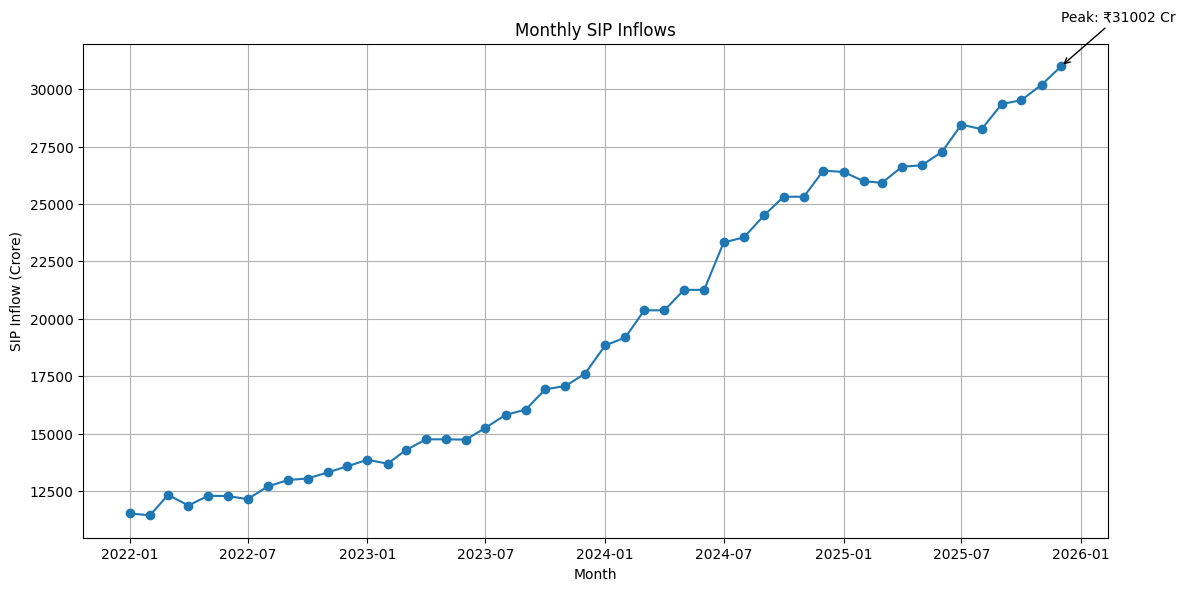

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
sip["month"] = pd.to_datetime(sip["month"])
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.annotate(
    f"Peak: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(max_row["month"], max_row["sip_inflow_crore"] + 2000),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.tight_layout()
plt.savefig("../charts/sip_inflow_trend.png")
plt.show()

In [7]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


## Category Inflow Trends

This analysis compares monthly inflows across mutual fund categories to understand investor preferences over time.

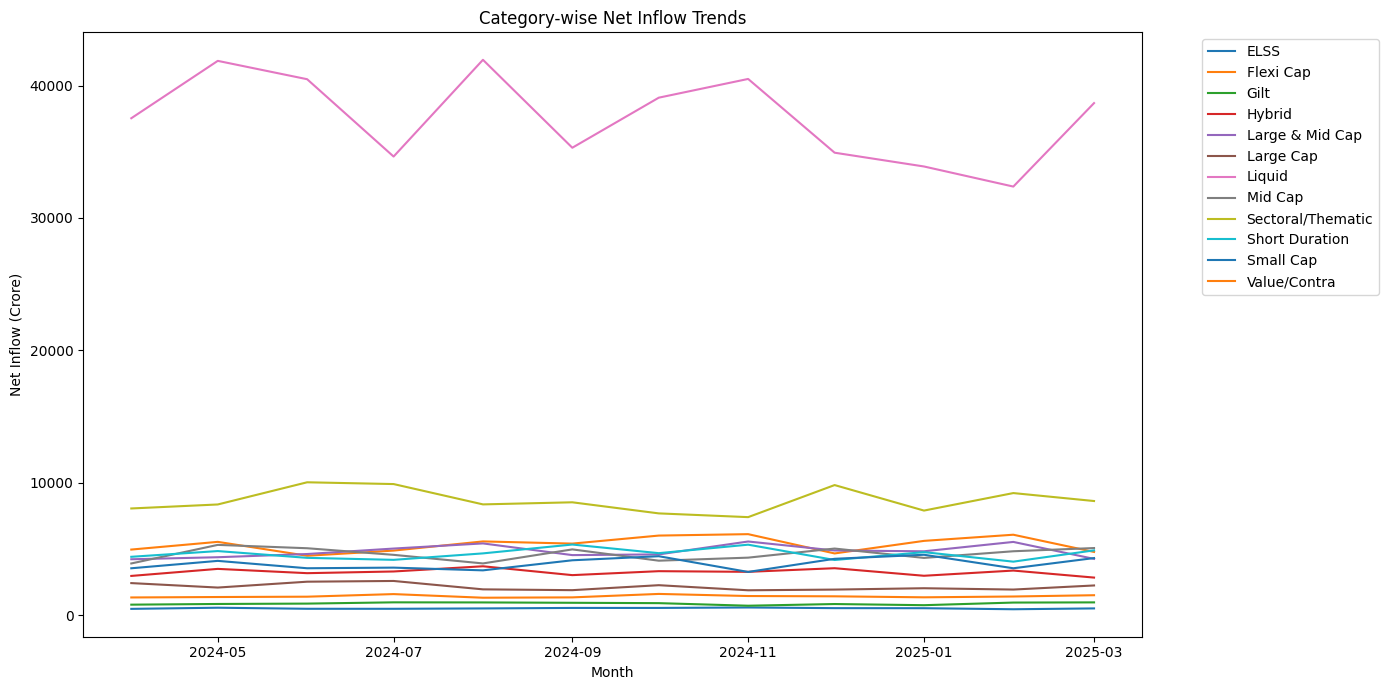

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

category = pd.read_csv("../data/processed/05_category_inflows.csv")
category["month"] = pd.to_datetime(category["month"])

pivot = category.pivot(
    index="month",
    columns="category",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,7))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        label=col
    )

plt.title("Category-wise Net Inflow Trends")
plt.xlabel("Month")
plt.ylabel("Net Inflow (Crore)")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("../charts/category_inflow_trends.png")

plt.show()

In [5]:
category.groupby("category")["net_inflow_crore"].sum().sort_values(ascending=False)

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

## Industry Folio Growth Analysis

1) This chart tracks the growth of mutual fund folios over time.

2) An increasing folio count indicates broader investor participation in the mutual fund industry.

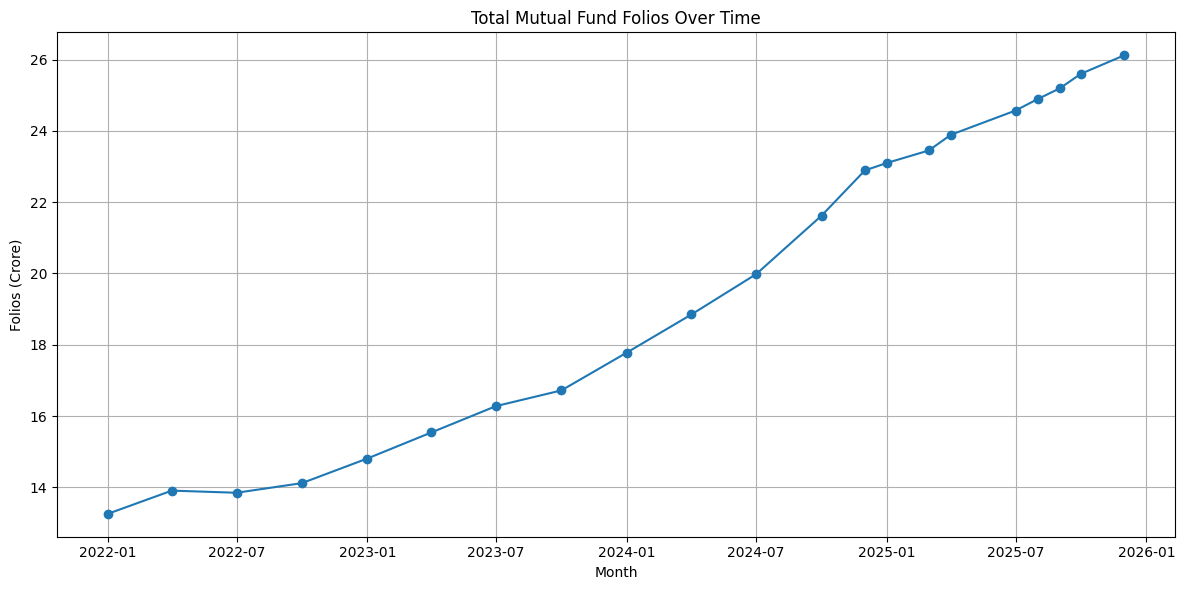

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

folios = pd.read_csv("../data/processed/06_industry_folio_count.csv")
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Total Mutual Fund Folios Over Time")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)
plt.tight_layout()
plt.savefig("../charts/folio_growth.png")

plt.show()

In [8]:
print(
    "Starting Folios:",
    folios["total_folios_crore"].iloc[0]
)

print(
    "Ending Folios:",
    folios["total_folios_crore"].iloc[-1]
)

Starting Folios: 13.26
Ending Folios: 26.12


## Risk vs Return Analysis

1) This scatter plot compares 3-year returns against annualized volatility for mutual fund schemes.

2) It helps identify funds that deliver higher returns for a given level of risk.

3) SBI Small Cap Fund delivered the highest 3-year return of 23.39% among all schemes analyzed.

4) However, it also exhibited one of the highest volatility levels (25%), indicating that higher returns were associated with higher risk.

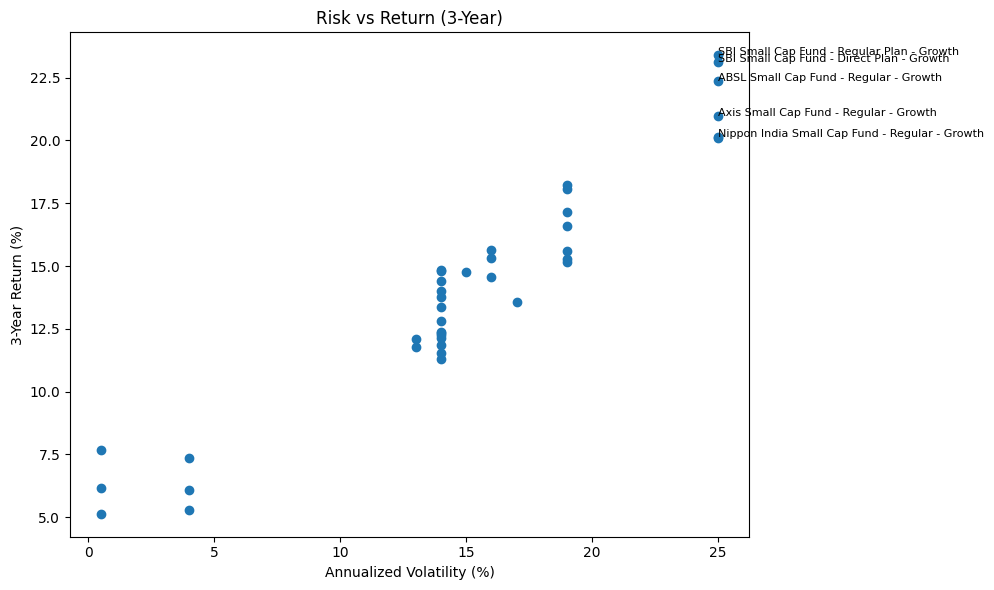

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

perf = pd.read_csv("../data/processed/clean_scheme_performance.csv")
plt.figure(figsize=(10,6))

plt.scatter(
    perf["std_dev_ann_pct"],
    perf["return_3yr_pct"]
)

top5 = perf.nlargest(5, "return_3yr_pct")

for _, row in top5.iterrows():
    plt.annotate(
        row["scheme_name"],
        (
            row["std_dev_ann_pct"],
            row["return_3yr_pct"]
        ),
        fontsize=8
    )

plt.title("Risk vs Return (3-Year)")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("3-Year Return (%)")

plt.tight_layout()

plt.savefig("../charts/risk_vs_return.png")

plt.show()

In [12]:
top_return = perf.loc[
    perf["return_3yr_pct"].idxmax()
]

print(
    top_return[
        ["scheme_name",
         "return_3yr_pct",
         "std_dev_ann_pct"]
    ]
)

scheme_name        SBI Small Cap Fund - Regular Plan - Growth
return_3yr_pct                                          23.39
std_dev_ann_pct                                          25.0
Name: 2, dtype: object


## Sector Allocation Analysis

This chart shows how portfolio holdings are distributed across sectors.
Sector concentration helps identify which industries receive the highest allocation from mutual fund managers.
The top sectors account for a significant share of total portfolio weight, while defensive and niche sectors receive comparatively lower allocations.

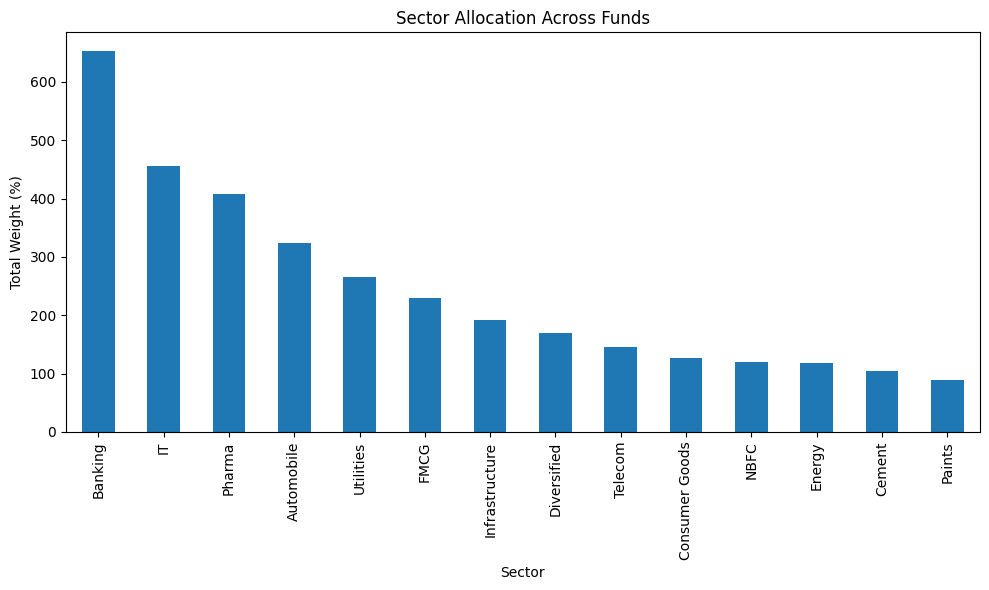

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sector_weights.plot(
    kind="bar"
)

plt.title("Sector Allocation Across Funds")
plt.xlabel("Sector")
plt.ylabel("Total Weight (%)")

plt.tight_layout()

plt.savefig("../charts/sector_allocation.png")

plt.show()

In [14]:
print(sector_weights.head(5))

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64


## Investor Demographics

This analysis examines investor participation across different age groups.
Understanding age distribution helps identify the primary investor segments driving mutual fund investments.

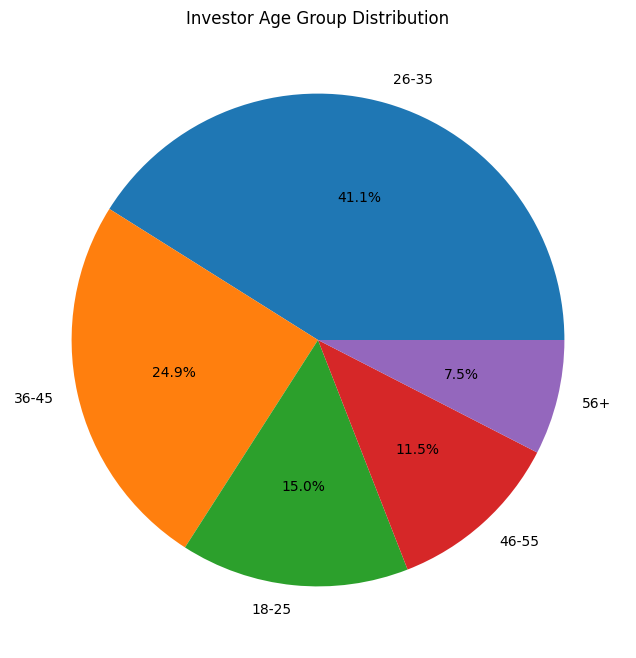

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

investors = pd.read_csv("../data/processed/clean_investor_transactions.csv")
age_counts = investors["age_group"].value_counts()
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.savefig("../charts/age_distribution.png")

plt.show()

## Insight

The mutual fund investor base is concentrated in a few age groups, indicating that investment participation is driven primarily by working-age individuals.

## Geographic Distribution of Investors

This analysis examines investor participation across different states.
Regional concentration helps identify markets with stronger mutual fund adoption.

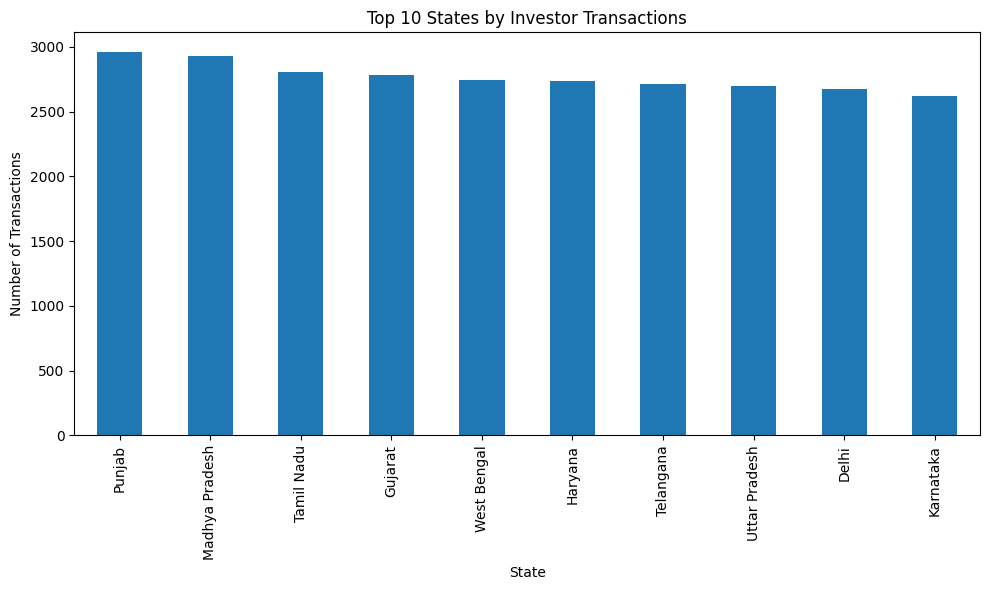

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

investors = pd.read_csv("../data/processed/clean_investor_transactions.csv")
state_counts = (
    investors["state"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

state_counts.plot(
    kind="bar"
)

plt.title("Top 10 States by Investor Transactions")
plt.xlabel("State")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../charts/state_distribution.png")

plt.show()

## Insight

1) Investor activity is concentrated in a handful of states, suggesting stronger awareness and adoption of mutual fund products in these regions.

2) The top states contribute a significant proportion of total transactions, highlighting important target markets for fund houses.